In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from Tools.data_utils import SimulationData, lorenz_stochastic

In [ ]:
# Parametri simulazione
n_steps = 10000
dt = 0.01
alpha = 0
beta = 0

# Parametri embedding
tau = 15
embedding_dim = 20
legendre_dim= 10

p_eff = (n_steps- embedding_dim*tau)/tau +1 # (p - d) + 1 nel paper
print("p_eff from this embedding parameters: ", int(p_eff))

# Crea una nuova istanza
simulation = SimulationData(n_steps, dt, alpha, beta, tau, embedding_dim, legendre_dim)

# Esegui la simulazione
simulation.run_simulation(lorenz_stochastic)

# Genera le osservabili
simulation.generate_observables()

#TO DO: Opzione per normalizare o meno i dati
# Normalizza i dati
simulation.normalize_data()


# Ottimizza: togli la creazione degli embedding e lascia solo matrici di Hankel
# Normalizza i dati o no e da li generi matrici di Hankel in modo da cambiare normalizzazione velocemente
#

# Crea gli embedding delle osservabili
simulation.create_embeddings()

# Crea le Matrici di Hankel
simulation.create_Hankel_Matrices() 

# Proietta sulla base di polinomi di Legendre
simulation.project_on_legendre()  # Matrice dimensione r x (p+d)-1


print("y1 shape: ", simulation.y1.shape)
print("y2 shape: ", simulation.y2.shape)
print("y1_embedding shape: ", simulation.y1_embedding.shape)
print("y2_embedding_1 shape: ", simulation.y2_embedding_1.shape)
print("y2_embedding_2 shape: ", simulation.y2_embedding_2.shape)
print("Hankel shape: ", simulation.H1.shape)
print("Projected Hankel shape: ", simulation.projected_H1.shape)



p_eff from this embedding parameters:  647
y1 shape:  (10000,)
y2 shape:  (10000, 2)
y1_embedding shape:  (9715, 20)
y2_embedding_1 shape:  (9715, 20)
y2_embedding_2 shape:  (9715, 20)
Hankel shape:  (20, 648)
Projected Hankel shape:  (10, 648)


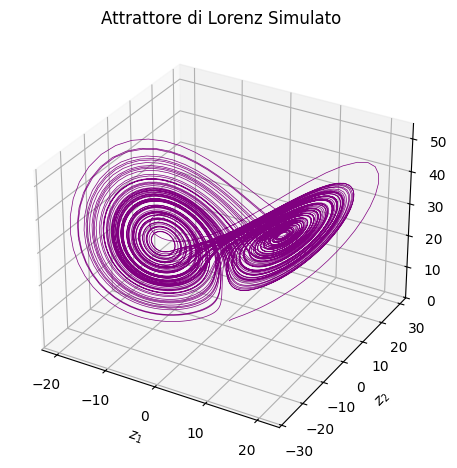

In [4]:
# Grafico delle traiettorie 
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax = fig.add_subplot(121, projection="3d")
ax.plot(simulation.trajectory[:, 0], simulation.trajectory[:, 1], simulation.trajectory[:, 2], color='purple', lw=0.5)
ax.set_title("Attrattore di Lorenz Simulato")
ax.set_xlabel(f"$z_1$")
ax.set_ylabel(f"$z_2$")
ax.set_zlabel(f"$z_3$")
plt.show()


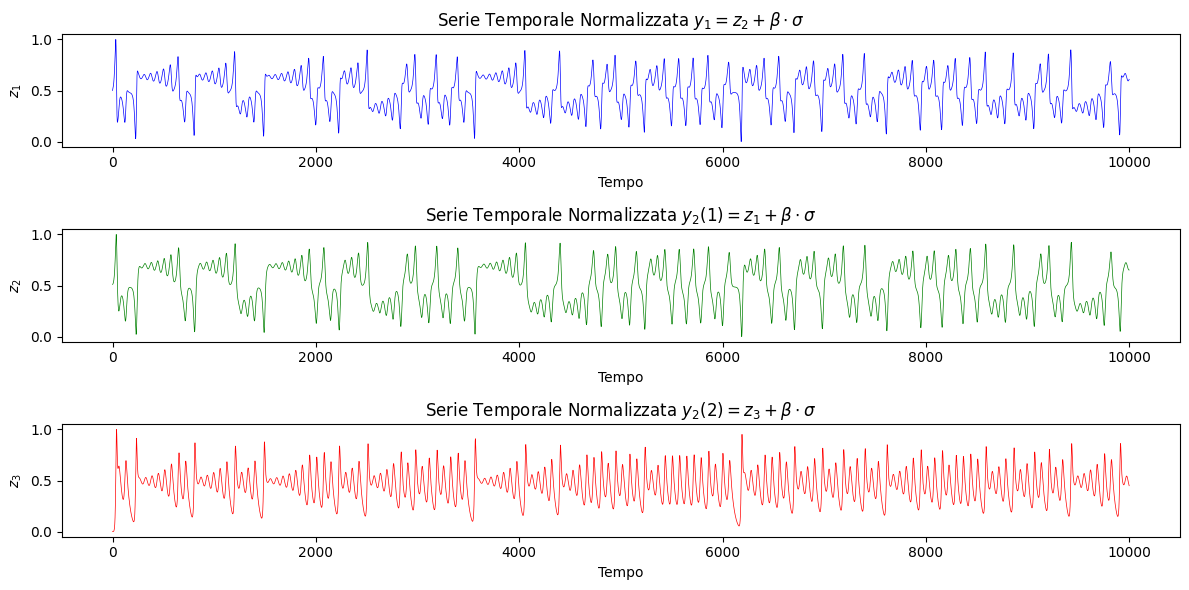

In [5]:
# Grafico delle serie temporali
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax1 = fig.add_subplot(311)
ax1.plot(simulation.y1_norm, color='blue', lw=0.5)
ax1.set_title(r"Serie Temporale Normalizzata $y_1 = z_2 + \beta \cdot \sigma$")
ax1.set_xlabel("Tempo")
ax1.set_ylabel("$z_1$")

ax2 = fig.add_subplot(312)
ax2.plot(simulation.y2_norm[:,0], color='green', lw=0.5)
ax2.set_title(r"Serie Temporale Normalizzata $y_2(1) = z_1 + \beta \cdot \sigma$")
ax2.set_xlabel("Tempo")
ax2.set_ylabel("$z_2$")

ax3 = fig.add_subplot(313)
ax3.plot(simulation.y2_norm[:,1], color='red', lw=0.5)
ax3.set_title(r"Serie Temporale Normalizzata $y_2(2) = z_3 + \beta \cdot \sigma$")
ax3.set_xlabel("Tempo")
ax3.set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

In [8]:
max_value = np.max(simulation.projected_H1)
min_value = np.min(simulation.projected_H1)

print("Valore massimo della matrice P:", max_value)
print("Valore minimo della matrice P:", min_value)

Valore massimo della matrice P: 1.0
Valore minimo della matrice P: -1.0


In [7]:
sim_name = simulation.generate_filename()
output_folder = "Simulation data"

file_path = os.path.join(output_folder, sim_name)
print(file_path)

simulation.save_to_file(file_path)
print("Simulation data saved to file")


Simulation data/delay15dim20,10_noise0,0.json


Simulation data saved to file
